# Interactive Script: **Initial Data Cube**

**Author:** Baturalp Arisoy<br>
**Contact:** baturalp.arisoy@uni-wuerzburg.de - Call me Batu :)

## Overview
This notebook guides the user through the essentials of generating an initial EO data cube. Besides, further chapters contain examples of how to read, write and process the data cube structure obtained by the function.

## Contents

Essentials:

1. [How to Generate Initial Data Cube](#1-how-to-generate-initial-data-cube)
2. [Visualization Tools](#2-visualization-tools)
3. [Export Data Arrays](#3-export-data-arrays)
    - 3.1. [Export as NETCDF](#3.1-export-as-netcdf)
    - 3.2. [Export as Cloud Optimized Geotifs (COGs)](#3.2-export-as-cloud-optimized-geotifs-(cogs))
4. [Read a NETCDF file](#4-read-a-netcdf-file)
5. [Update Data Cube](#5-update-data-cube)

Further Tools:

6. [Slice Time and Band](#6-slice-time-and-band)
7. [Calculate Stats](#7-calculate-stats)
8. [Further Time Series Tools](#8-further-time-series-tools)
9. [Examples for Other Missions](#9-examples-for-other-missions)
    - 9.1. [Sentinel-1](#9.1-sentinel-1)
    - 9.2. [Landsat](#9.2-landsat)
    - 9.3. [COP DEM GLO-30](#9.3-cop-dem-glo-30)

---

## Import

In [1]:
from stac2cube import get_stac_layers, missions, show_parameter_help
import xarray as xr
import dask
from dask.diagnostics import ProgressBar

## 1. How to Generate Initial Data Cube

### 1.1. Set the parameters

**Run this cell to display parameter help** <br> Can collapse the cell to have a clearer view

In [ ]:
show_parameter_help(open_by_default=False)

ToggleButton(value=False, description='Show parameter help', icon='info-circle', tooltip='Click to show/hide t…

Output()

(ToggleButton(value=False, description='Show parameter help', icon='info-circle', tooltip='Click to show/hide the parameter documentation'),
 Output())

In [ ]:
# Run this to see what parameters can be set in the next cell.
missions()

In [ ]:
mission = "s2"
output = None
polygon = "./polygons/test.gpkg"
resolution = 10
daterange = ["2024-04-01", "2024-04-10"]
bands = ["blue", "green", "red", "nir"]
indices = ["ndvi", "ndwi"]
clip_raster = False
max_cc = 100
cloud_masking = False
stats = None # e.g. ["mean", "median", "std", "min", "max"]
aggregator = None #e.g. "mean" or "median"
q = None

#### (Optional) If polygon is not available, select your area below on Leafmap

In [ ]:
# You can copy one those following basemaps and paste in the next cell -> add_basemap("basemap"). IF you skip this, default is OSM.
# You can also use settings button on right top of the leafmap to change basemap however, that button does not work on some browsers.
import leafmap
print(leafmap.basemaps.keys())

In [ ]:
# Select draw polygon from the left top of the map (recommended: rectangle), draw your polygon and execute the NEXT cell
# Note: If the user select polygon other than rectangle & square shape, the code will automatically return bbox of the shape. In case the user wish to use customized shape of polygon, import a vector file and set clip_raster True above. Well, until this feature is updated!
# Note: If the leafmap window has an absurd size, you can click view full screen button on the left of the map. 

import leafmap
m = leafmap.Map(center=[49.787281735930804, 9.978161492015976], zoom=18, height="800px")
#m.add_basemap("Esri.WorldImagery")

m.layout.height = "65vh"
m.layout.max_height = "700px"
m.layout.min_height = "320px"
m.layout.width = "80%"
m

In [6]:
# This will be take above drawn polygon as the new polygon (will overwrite previously set polygon parameter)
polygon_map = m.user_roi
ring = polygon_map["geometry"]["coordinates"][0]
xs = [x for x, y in ring]
ys = [y for x, y in ring]
polygon = [min(xs), min(ys), max(xs), max(ys)]  # [xmin, ymin, xmax, ymax]
polygon

[28.937688, 41.007366, 29.05585, 41.070293]

### 1.2. Build Initial Data Cube

In [3]:
stac = get_stac_layers(mission=mission, polygon=polygon, resolution=resolution, 
                            daterange=daterange, bands=bands, max_cc=max_cc, 
                            clip_raster=clip_raster, cloud_masking=cloud_masking, indices=indices, 
                            output=output, aggregator=aggregator, stats=stats, q=q
                            )

# You can check metadata of the data cube in attributes section.

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 4, band: 6, y: 722, x: 1010)> Size: 140MB
dask.array<transpose, shape=(4, 6, 722, 1010), dtype=float64, chunksize=(1, 1, 722, 1010), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 32B 2024-04-01 2024-04-03 ... 2024-04-08
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * y            (y) float64 6kB 4.549e+06 4.549e+06 ... 4.541e+06 4.541e+06
  * x            (x) float64 8kB 6.628e+05 6.628e+05 ... 6.729e+05 6.729e+05
    spatial_ref  int32 4B 0
Attributes:
    nodata:          0
    indices:         ['ndvi', 'ndwi']
    spectral_bands:  ['blue', 'green', 'red', 'nir']
    mission:         sentinel_2_l2a
    tile_id:         ['35TPF']
    bbox:            [28.937688, 41.007366, 29.05585, 41.070293]
    crs:             WGS 84 / UTM zone 35N
    transform:       | 10.00, 0.00, 662790.00|\n| 0.00,-10.00, 4548600.00|\n|...


**You can also check the rough size of the data cube after export**

In [4]:
def format_bytes(n: int) -> str:
    units = ["B", "KiB", "MiB", "GiB", "TiB", "PiB"]
    f = float(n)
    for u in units:
        if f < 1024 or u == units[-1]:
            return f"{f:.2f} {u}" if u != "B" else f"{int(f)} {u}"
        f /= 1024

def lazy_data_size(da: xr.DataArray) -> str:
    return format_bytes(da.nbytes)

print(lazy_data_size(stac))

133.52 MiB


**If time coordinate is too long to be printed**

In [ ]:
print(stac.time.values)
# Click "View as a scrollable element" below if some dates are hidden.

### 1.3. (OPTIONAL) Compute the Data Cube

> **Note:**
> You can compute the data cube before exporting but this is just optional. Exporting at 3rd chapter already computes and exports your cube!<br><br>
> **Compute if** you want to experience following visualization tools with high speed. <br><br>
> **Skip if** you are unsure of your data and study area, do not compute and use visualization tools with a bit slow speed.

In [ ]:
if dask.is_dask_collection(stac):
    with ProgressBar():
        stac = stac.compute()

## 2. Visualization Tools

> **Information:**
> Time series tools can be applied to lazy stacs. The performance of widgets will be based on user's local machine instead of terrabyte cluster.

> **Note:**
> Display mode options for following tools: 'rgb', 'ndvi', 'ndwi'

> **Note:**
> Does not work with mean or median if you activated aggregation at Chapter 1!

In [6]:
from stac2cube import interactive_time_view, generate_animation
import matplotlib.pyplot as plt
import numpy as np

### 2.1 Interactive Time View

> **Note:**
> If dataarray is lazy, the following tools could take a little time reload every time a date is selected. Please be patient and remember the speed is based on your local machine.<br>
> If datarray is already computed, then the tools will function quickly.

#### 2.1.1 Slider

In [ ]:
interactive_time_view(stac=stac, display_mode='rgb', widget_type='slider')

#### 2.1.2 Dropdown

In [ ]:
interactive_time_view(stac=stac, display_mode='rgb', widget_type='dropdown')

### 2.2 Animation

In [ ]:
output_path = "./animations/test_animation.gif"
display_mode = "rgb"

generate_animation(stac=stac, output_path=output_path, display_mode=display_mode, frame_interval_ms=200) # lower frame interval faster animation & higher frame slower animation

## 3. Export Data Arrays

### 3.1 Export as NETCDF

> **Information:**
> Geotiff files cannot handle 4 dimensional (time, band, x, y) arrays, therefore NETCDF is one the multi-dimensional formats to export time series. 

> **Note for QGIS Users:**
> When NETCDF imported to QGIS, the software won't recognize band names and time dates. You need to know the order of your bands to proceed visualizations in QGIS. <br><br>
> If this does not work for you, proceed to 3.2 Export as Cloud Optimized Geotifs<br><br>
> Order of the bands in our example you can find at stac datarray. In our example: 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'

In [ ]:
from stac2cube import export_stac

export_stac(stac, "./results/test.nc")

> **Note for potato computer owners:**
> If the process takes too long and eventually fails due to unsufficient memory (e.g. low spec local machine), you can select narrower date range then use updating mechanism, see Chapter 9.<br><br>
With updating mechanism, for example, instead of computing 8 years of data, update every year range seperately.<br><br>
The problem is not with exporting itself but computation of arrays, therefore, splitting computations is a good strategy if the local machine is not strong enough. Divide and conquer!

### 3.2 Export as Cloud Optimized Geotiffs (COGs)

> **Note:**
> Geotiff format cannot handle 4 dimensional system. Therefore each time has to be exported separately. But hey good news, band names will be recognized in QGIS.

In [ ]:
from stac2cube import export_to_cogs
export_to_cogs(stac, "./results/cogs/")

## 4. Read a NETCDF file

> **Note:**
> Reading exported NETCDF file is essential to work with time series later in case you would like to do further analysis and statistics, or apply machine learning algorithms.

> **Note:**
> If the stac is exported with output and stats are selected, you will have multiple layers. Spectral Temporal Stack and the selected stats.<br><br>
> Let's export another test but with stats this time.

In [ ]:
from stac2cube import get_stac_layers
import xarray as xr

### 4.1 Export Another NETCDF with Stats for Test Purposes

In [ ]:
mission = "s2"                
output = "./results/test_stats.nc"
polygon = "./polygons/test.gpkg"
resolution = 10                             
daterange = ["2024-04-01", "2024-04-07"]
bands = ["blue", "green", "red", "nir"]     
indices = ["ndvi", "ndwi"]                  
clip_raster = False
max_cc = 100
cloud_masking = False
stats = ["mean", "median", "min", "max", "std"]
aggregator = None

stac_stats = get_stac_layers(mission=mission, polygon=polygon, resolution=resolution, 
                            daterange=daterange, bands=bands, max_cc=max_cc, 
                            clip_raster=clip_raster, cloud_masking=cloud_masking, indices=indices, 
                            output=output, aggregator=aggregator, stats=stats, q=True # YOU CAN q=True to activate silent mode without print statements
                            )

### 4.2 Read DATASET

> **Information:**
> Data Variables of an xarray dataset consist of **Spectral_Temporal_Stack** (original time series), and **single images per selected stat**.

In [ ]:
img = ("./results/test_stats.nc")

with xr.open_dataset(img) as ds:
    dataset =ds.load()

dataset

### 4.3 Read Original Time Series from Dataset

**Selecting Spectral_Temporal_Stack brings original time series**

In [ ]:
dataarray = dataset.Spectral_Temporal_Stack
dataarray

### 4.4 Read Different Stats from Dataset

> **Note:**
> If STAC is exported with option **stats**, each stat is stored as seperate data array.

In [ ]:
dataarray_mean = dataset.mean_imagery
dataarray_mean

## 5. Update Data Cube

> **Information:**
> Two reasons to update your data cube <br><br>
> 1. Extending the date range and recalling a data cube will compute everything from the beginning. Too much processing power, especially if you regularly update your 8 years of data!<br><br>
> 2. If the local machine is low spec and cannot handle long term time series, instead generate a short range inital data cube and step by step update the cube below. (example year per year)

In [1]:
from stac2cube import get_stac_layers
import xarray as xr

### 5.1 Read an exported NETCDF Data Cube

In [ ]:
img = "./results/test.nc"

with xr.open_dataset(img) as ds:
    stac = ds["Spectral_Temporal_Stack"].load()

In [ ]:
stac.time.values

### 5.2 Select parameters

> **Note:**
> Parameters given in bold will be overwritten. Therefore, they don't have to be part of updating mechanism, but even if they do, won't have any effect: **mission, resolution, polygon, bands, indices, output** <br><br>
> These parameters will be overwritten by the metadata stored in attributes of a dataarray.

In [3]:
update = "./results/test.nc"
daterange = ["2024-04-01", "2024-04-12"]
max_cc = 100
clip_raster = False # does not work for now, keep it False
cloud_masking = False
stats = None
aggregator = None

### 5.3 Update STAC

In [4]:
stac = get_stac_layers(update=update, daterange=daterange,
                        max_cc=max_cc, clip_raster=clip_raster,
                        cloud_masking=cloud_masking,
                        stats=stats, aggregator=aggregator, q=True)

1 new date found!
Update Report:
-------------------------
1 new date have been integrated into the dataset.
The following dates were added:
 - 2024-04-11
-------------------------
Export is done: ./results/test.nc


In [ ]:
stac.time.values

FURTHER TOOLS

## 6. Slice Time and Band

> **Note:**
> Once you are done with slicing data cube, you can go back to Chapter 3 to export the data. Don't forget to change input parameter!

### 6.1. Slice Time

#### 6.1.1 Slice Single Date

**By exact date**

In [ ]:
date = "2024-04-01"
stac_single_date = stac.sel(time=date)

In [ ]:
stac_single_date

#### 6.1.2 Slice Time Range

In [ ]:
daterange = ["2024-04-01", "2024-04-06"]
stac_time_range = stac.sel(time=slice(*daterange))
stac_time_range

#### 6.1.3 Slice Multiple Dates

In [ ]:
dates = ['2024-04-01', '2024-04-06']
stac_multi_dates = stac.sel(time=dates)
stac_multi_dates

### 6.2. Slice Bands

#### 6.2.1 Slice Single Band

In [ ]:
band = 'ndvi'
stac_ndvi = stac.sel(band=band)
stac_ndvi

#### 6.2.2 Slice Multiple Bands

In [ ]:
bands = ['red', 'green', 'blue']
stac_rgb = stac.sel(band=bands)
stac_rgb

### 6.3 Slice both Time and Band

In [ ]:
daterange = ["2024-01-01", "2024-12-31"]
bands = ['red', 'green', 'blue']

stac_2024 = stac.sel(time=slice(*daterange))
stac_2024_rgb = stac_2024.sel(band=bands)
stac_2024_rgb

## 7. Calculate Stats

> **Note:**
> Following calculation don't need to be done if the user sets stats when building initial data cube.<br><br>
> However, if you slice time range from initial data cube, you can use the following section to calculate stats.

> **Note:**
> Once you are done with stat calculation you can go back to Chapter 3 to export the data. Don't forget to change input parameter!

### 7.1 Calculate a single stat for a given daterange

In [ ]:
daterange = ["2024-04-01", "2024-04-10"]
stac_range = stac.sel(time=slice(*daterange))
stac_range_mean = stac_range.mean(dim='time')
stac_range_mean

### 7.2 Calculate selected stats for a given daterange

In [21]:
daterange = ["2024-01-01", "2024-12-31"]
stac_range = stac.sel(time=slice(*daterange))

stats = ['mean', 'median', 'std', 'max', 'min']
stac_range_stats = {stat: getattr(stac_range, stat)(dim='time') for stat in stats}

In [ ]:
stac_range_stats

**Select the desired stat**

In [ ]:
median = stac_range_stats['median']
median

> **Note:**
> Median for example can be used as input parameter and exported as new NETCDF at Chapter 3 

## 8. Further Time Series Tools

### 8.1 Time Series Graph

> **Note:**
> Following mean calculation over x and y coordinates requires **computation**. Therefore, if stac is lazy array, then it will take time. For faster experience, export with SLURM, then read NETCDF file and get Spectral Temporal Stack.

In [24]:
ds = xr.open_dataset("./results/orog_1_noclip.nc")
da = ds.Spectral_Temporal_Stack

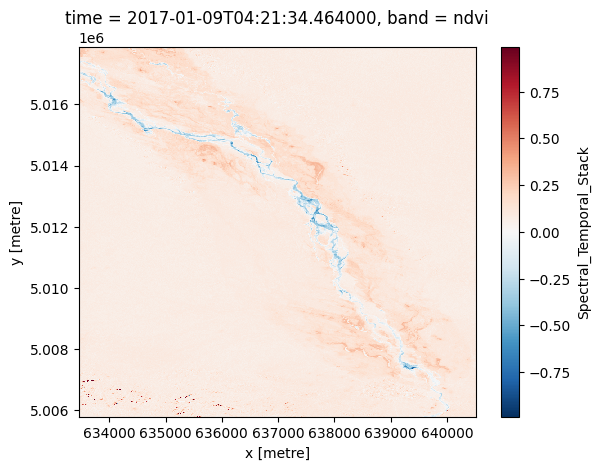

In [34]:
da[0][4].plot()

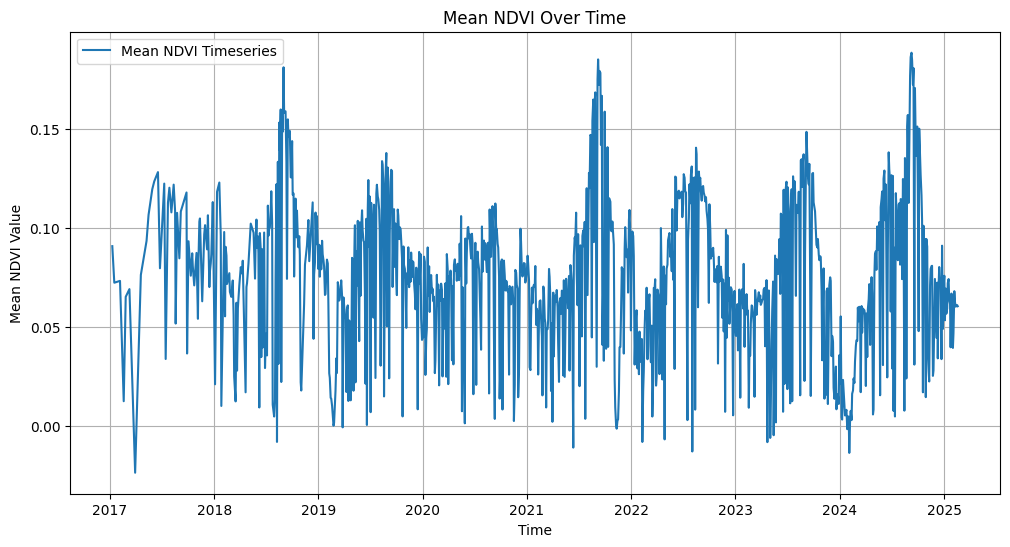

In [4]:
band = "ndvi"

da_sel = da.sel(band=band)
da_sel = da_sel.mean(dim=["x", "y"])

# Plot the values over time
plt.figure(figsize=(12, 6))
plt.plot(da_sel["time"], da_sel, label="Mean NDVI Timeseries")
plt.xlabel("Time")
plt.ylabel("Mean NDVI Value")
plt.title("Mean NDVI Over Time")
plt.legend()
plt.grid()
plt.show()

**Smoothed series**

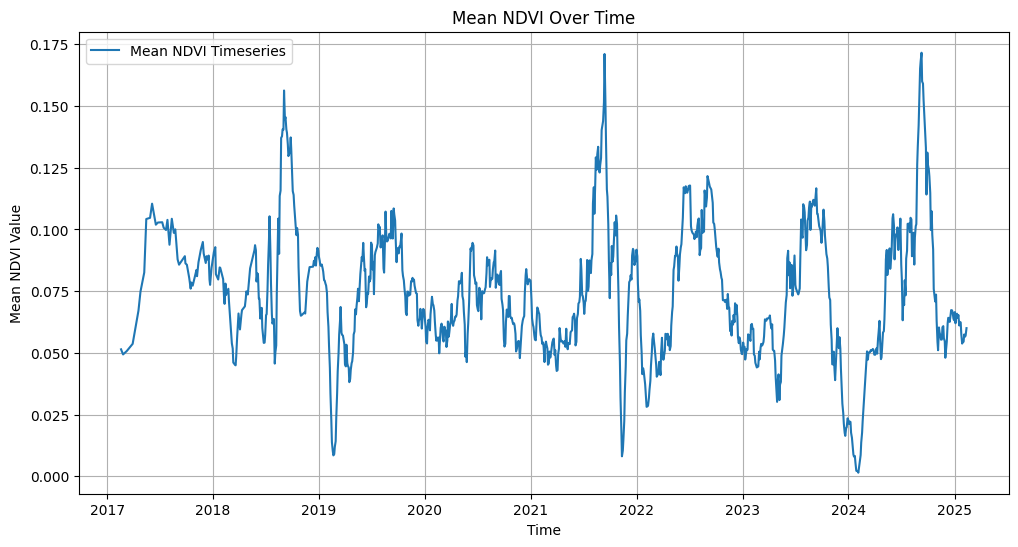

In [5]:
smoothed_da = da_sel.rolling(time=7, center=True).mean()
plt.figure(figsize=(12, 6))
plt.plot(smoothed_da["time"], smoothed_da, label="Mean NDVI Timeseries")
plt.xlabel("Time")
plt.ylabel("Mean NDVI Value")
plt.title("Mean NDVI Over Time")
plt.legend()
plt.grid()
plt.show()

### 8.2 Export Time Series as CSV

In [ ]:
import pandas as pd

# Select bands/indices, stats and export path
da = da.sel(band=["ndvi", "ndwi"])
stats = ["mean", "median"]
export_path = "./results/timeseries.csv"

bands = da.coords['band'].values
df_list = []
for band in bands:
    da_band = da.sel(band=band)
    base_stat = stats[0]
    df_band = getattr(da_band, base_stat)(dim=["x", "y"]).to_dataframe(name=base_stat).reset_index()[["time"]]
    df_band["band"] = band
    for stat in stats:
        df_band[stat] = getattr(da_band, stat)(dim=["x", "y"]).values
    df_band["time"] = df_band["time"].dt.date  
    df_list.append(df_band)

df_all = pd.concat(df_list, ignore_index=True)
df_all = df_all.sort_values(by=["time", "band"])
df_all.to_csv(export_path, index=False)

### 8.3 (Multi)Seasonal-Trend decomposition using LOESS

In [7]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import MSTL

In [28]:
da_sel

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 1034)> Size: 8kB
array([0.09079285, 0.07235902, 0.0732902 , ..., 0.06055129, 0.06105204,
       0.06049898], shape=(1034,))
Coordinates:
    band     <U5 20B 'ndvi'
  * time     (time) datetime64[ns] 8kB 2017-01-09 2017-01-16 ... 2025-02-18

In [22]:
# 1. Select the 'ndvi' band and average over spatial dimensions (x, y)
da_sel = da.sel(band="ndvi").mean(dim=["x", "y"])
da_sel['time'] = da_sel['time'].dt.floor('D')

# 2. Convert the xarray DataArray to a Pandas Series
#    The Pandas Series will have a DatetimeIndex derived from the 'time' dimension.
ts = da_sel.to_series()

# 3. Resample the data to a regular daily frequency and fill gaps with linear interpolation.
#    This step is crucial because MSTL expects data with a constant time step.
ts_reg = ts.resample('D').interpolate(method='linear')

# 4. Define seasonal periods.
#    - Monthly: ~30 days (approximation)
#    - Quarterly: ~90 days (3 months)
#    - Annual: ~365 days (1 year)
seasonal_periods = [30, 90, 365]

In [24]:
ts_reg

time
2017-01-09    0.090793
2017-01-10    0.088159
2017-01-11    0.085526
2017-01-12    0.082893
2017-01-13    0.080259
                ...   
2025-02-14    0.060718
2025-02-15    0.060885
2025-02-16    0.061052
2025-02-17    0.060776
2025-02-18    0.060499
Freq: D, Name: Spectral_Temporal_Stack, Length: 2963, dtype: float64

In [61]:
mstl_result = MSTL(ts, periods=seasonal_periods).fit()

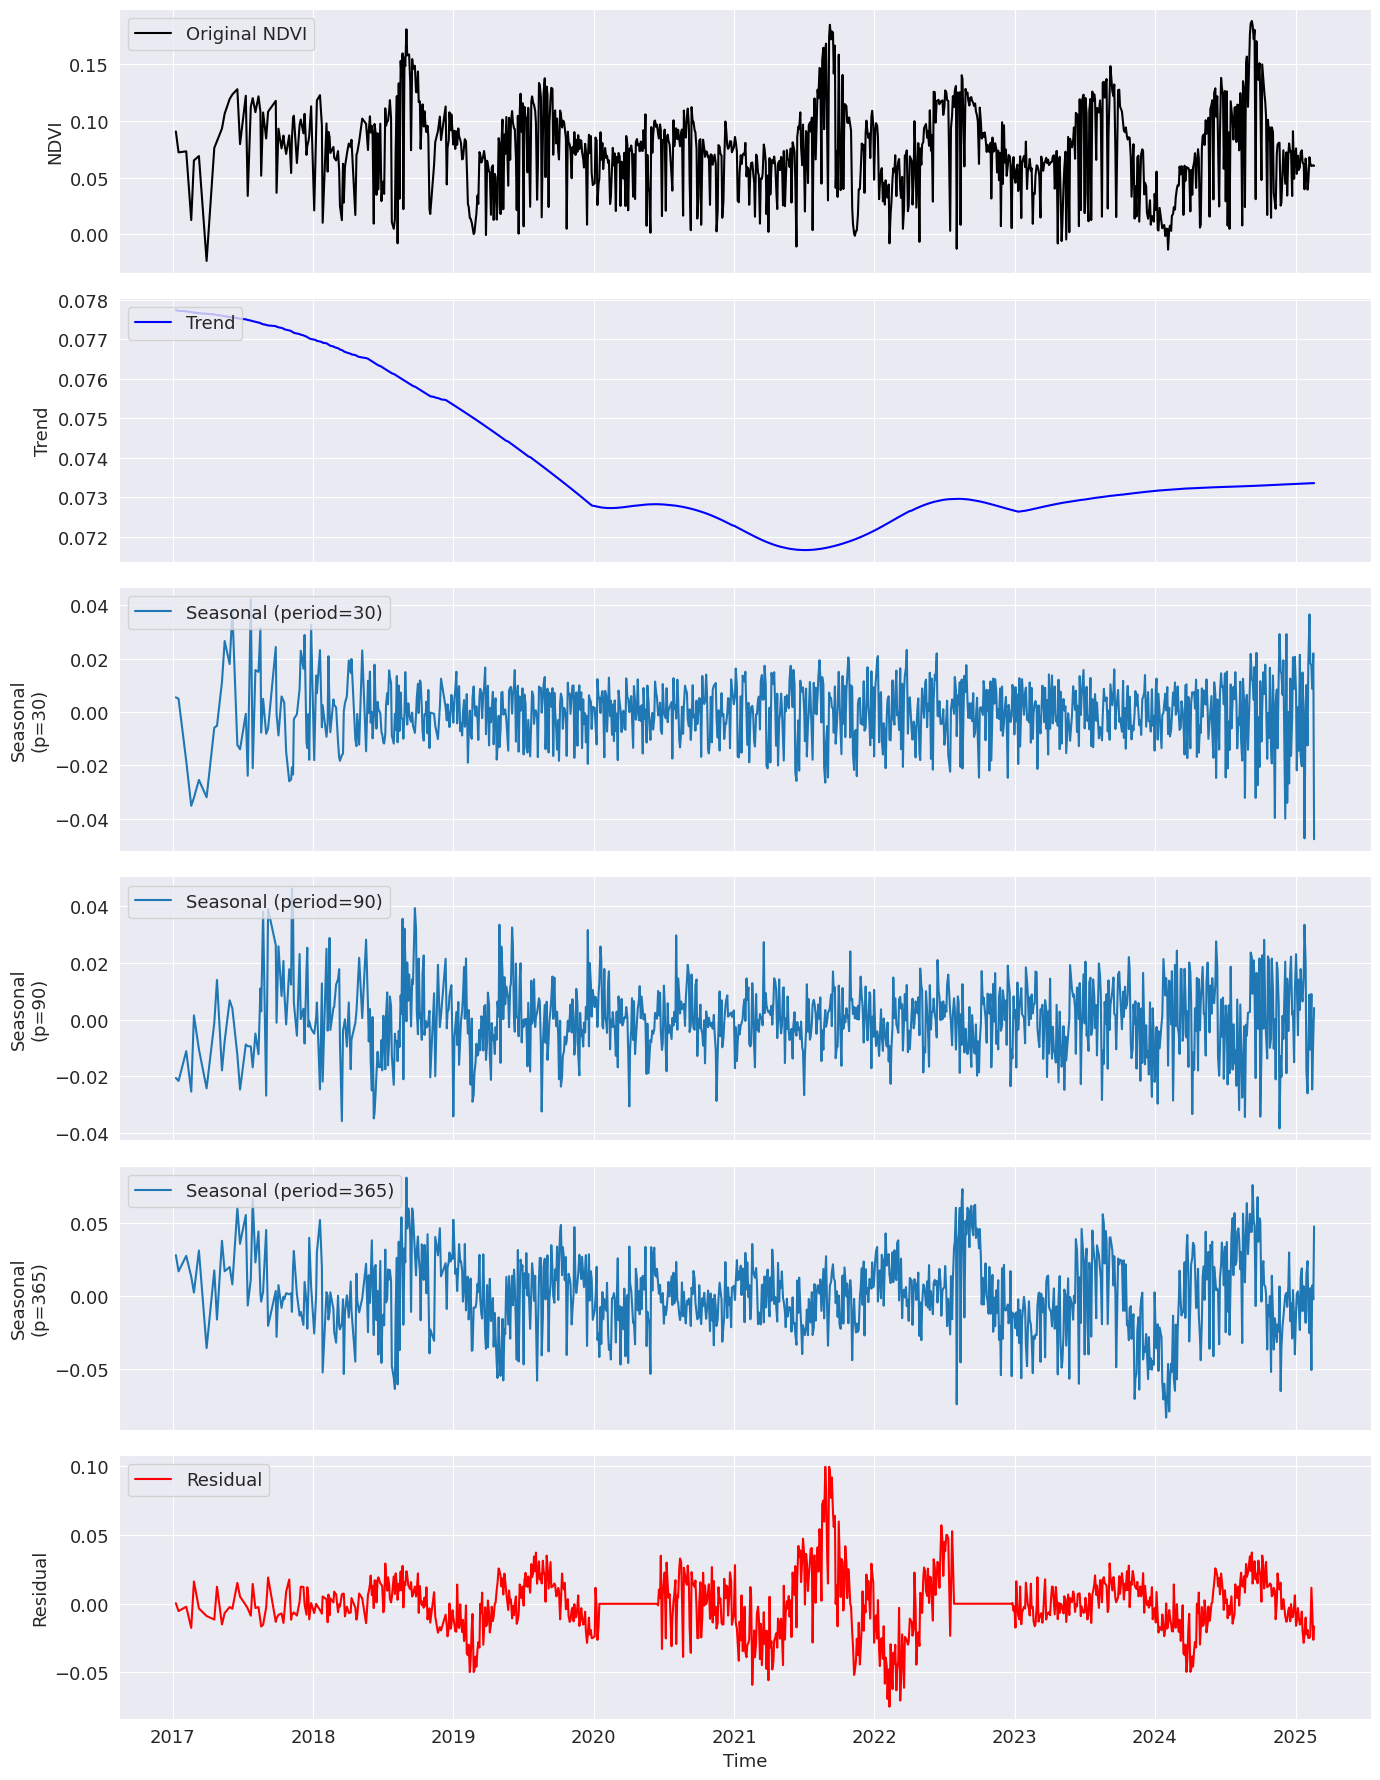

In [62]:
import matplotlib.pyplot as plt

n_seasons = len(seasonal_periods)

# Allocate 3+n_seasons subplots: original, trend, one for each season, and one for residuals.
fig, axs = plt.subplots(3 + n_seasons, 1, figsize=(14, 3*(3 + n_seasons)), sharex=True)

# 1. Plot original NDVI timeseries
axs[0].plot(ts_reg, label='Original NDVI', color='black')
axs[0].set_ylabel("NDVI")
axs[0].legend(loc='upper left')
axs[0].grid(True)

# 2. Plot trend component
axs[1].plot(mstl_result.trend, label='Trend', color='blue')
axs[1].set_ylabel("Trend")
axs[1].legend(loc='upper left')
axs[1].grid(True)

# 3. Plot each seasonal component separately
for i, period in enumerate(seasonal_periods):
    seasonal_component = mstl_result.seasonal.iloc[:, i]
    axs[2 + i].plot(seasonal_component, label=f'Seasonal (period={period})')
    axs[2 + i].set_ylabel(f'Seasonal\n(p={period})')
    axs[2 + i].legend(loc='upper left')
    axs[2 + i].grid(True)

# 4. Plot residuals in the last subplot
axs[-1].plot(mstl_result.resid, label='Residual', color='red')
axs[-1].set_ylabel("Residual")
axs[-1].legend(loc='upper left')
axs[-1].grid(True)

# Final layout adjustments
plt.xlabel("Time")
plt.tight_layout()
plt.show()


In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters

register_matplotlib_converters()
sns.set_style("darkgrid")

In [42]:
plt.rc("figure", figsize=(16, 12))
plt.rc("font", size=13)

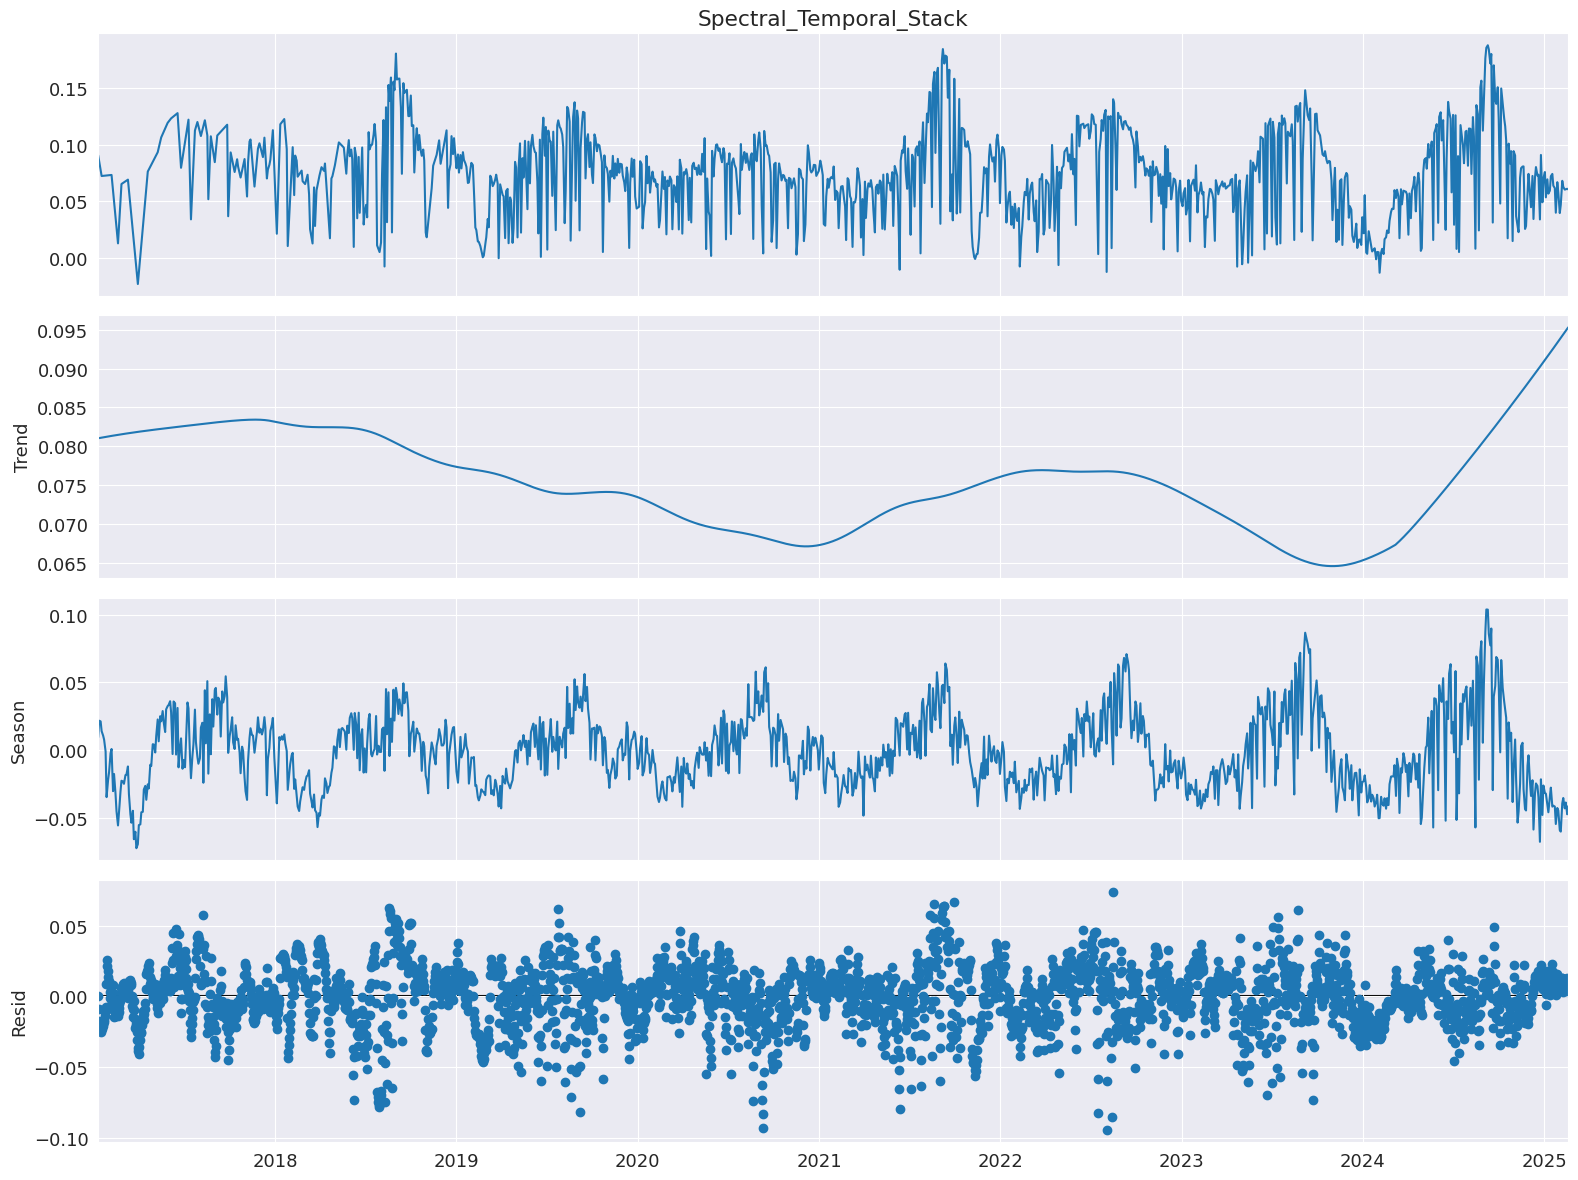

In [63]:
from statsmodels.tsa.seasonal import STL

stl = STL(ts_reg, period=365)
res = stl.fit()
fig = res.plot()

## 9. Examples for Other Missions

### 9.1 Sentinel-1

In [13]:
missions().iloc[2]

name                                                         sentinel_1_rtc
allias                                                                   s1
stac_catalog            https://planetarycomputer.microsoft.com/api/stac/v1
default_resolution                                                       10
bands                                                              [vh, vv]
indices                                                 [vh/vv, vv/vh, rvi]
topographic_features                                                  False
max_cc                                                                False
clip_raster                                                   [True, False]
cloud_masking                                                         False
output                                                    path/to/output.nc
aggregator                                                   [mean, median]
stats                                         [mean, median, std, min, max]
update      

In [14]:
mission = "s1"                              # both name and allias work. Can not be None!
polygon = "./polygons/test.gpkg"            
resolution = 10                             
daterange = ["2023-01-01", "2025-01-01"]    
bands = ["vh", "vv"]
indices = ["vh/vv", "vv/vh", "rvi"]
output = None    
clip_raster = False                                                    
stats = None                                
aggregator = None

In [15]:
stac = get_stac_layers(mission=mission, polygon=polygon, resolution=resolution, 
                            daterange=daterange, bands=bands,
                            clip_raster=clip_raster, indices=indices, 
                            output=output, aggregator=aggregator, stats=stats,
                        )

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 173, band: 5, y: 247, x: 511)> Size: 437MB
dask.array<transpose, shape=(173, 5, 247, 511), dtype=float32, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
    orbit_state  (time) <U10 7kB 'descending' 'descending' ... 'ascending'
  * band         (band) <U5 100B 'vh' 'vv' 'vh/vv' 'vv/vh' 'rvi'
  * time         (time) datetime64[ns] 1kB 2023-01-01 2023-01-06 ... 2024-12-27
    spatial_ref  int64 8B 0
Attributes:
    indices:         ['vh/vv', 'vv/vh', 'rvi']
    spectral_bands:  ['vh', 'vv']
    mission:         sentinel_1_rtc
    bbox:            [28.98752355404842, 41.03150270425637, 29.04759458831022...
    crs:             WGS 84 / UTM zone 35N
    transform:       | 10.00, 0.00, 667020.00|\n| 0.00,-10.00, 4546620.00|\n|...


#### Plot Map

In [16]:
def normalize(band, clip_percentile=2):
    band_min, band_max = np.nanpercentile(band, [clip_percentile, 100 - clip_percentile])
    if band_max == band_min:
        return np.zeros_like(band)
    band = np.clip(band, band_min, band_max)
    normalized = (band - band_min) / (band_max - band_min)
    normalized = np.nan_to_num(normalized, nan=0.5)
    return normalized

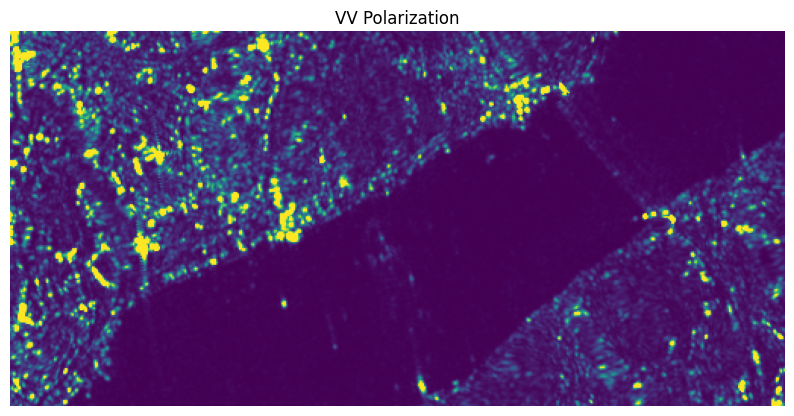

In [17]:
time_to_visualize = '2024-12-27'
bands = ["vv"]

da_time = stac.sel(time=time_to_visualize)
da_composite = da_time.sel(band=bands)
band1 = da_composite[0]
band1_normalized = normalize(band = band1)

# Plot the image
plt.figure(figsize=(10, 5))
plt.imshow(band1_normalized)
plt.title("VV Polarization")
plt.axis("off")
plt.show()

#### Select by orbit-state

In [18]:
orbit_state = "ascending"

stac_ascending = stac.where(stac.orbit_state == orbit_state, drop=True)
stac_ascending

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 56, band: 5, y: 247, x: 511)> Size: 141MB
dask.array<where, shape=(56, 5, 247, 511), dtype=float32, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
    orbit_state  (time) <U10 2kB 'ascending' 'ascending' ... 'ascending'
  * band         (band) <U5 100B 'vh' 'vv' 'vh/vv' 'vv/vh' 'rvi'
  * time         (time) datetime64[ns] 448B 2023-01-07 2023-01-19 ... 2024-12-27
    spatial_ref  int64 8B 0
Attributes:
    indices:         ['vh/vv', 'vv/vh', 'rvi']
    spectral_bands:  ['vh', 'vv']
    mission:         sentinel_1_rtc
    bbox:            [28.98752355404842, 41.03150270425637, 29.04759458831022...
    crs:             WGS 84 / UTM zone 35N
    transform:       | 10.00, 0.00, 667020.00|\n| 0.00,-10.00, 4546620.00|\n|...

In [56]:
orbit_state = "descending"

stac_descending = stac.where(stac.orbit_state == orbit_state, drop=True)
stac_descending

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 117, band: 5, y: 247, x: 511)> Size: 295MB
dask.array<where, shape=(117, 5, 247, 511), dtype=float32, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
    orbit_state  (time) <U10 5kB 'descending' 'descending' ... 'descending'
  * band         (band) <U5 100B 'vh' 'vv' 'vh/vv' 'vv/vh' 'rvi'
  * time         (time) datetime64[ns] 936B 2023-01-01 2023-01-06 ... 2024-12-26
    spatial_ref  int64 8B 0
Attributes:
    indices:         ['vh/vv', 'vv/vh', 'rvi']
    spectral_bands:  ['vh', 'vv']
    mission:         sentinel-1-rtc
    bbox:            [28.98752355404842, 41.03150270425637, 29.04759458831022...
    crs:             WGS 84 / UTM zone 35N
    transform:       | 10.00, 0.00, 667020.00|\n| 0.00,-10.00, 4546620.00|\n|...

> **Note:**
> Using **where()** argument breaks the CRS information of the data array. Might visualize with plotting function but will have some issues e.g. when netcdf file is imported to QGIS. Therefore assign the CRS before exporting!

In [58]:
# That's why crs information is embedded as data array attribute
stac_descending = stac_descending.rio.write_crs(stac_descending.crs, inplace=True)
stac_descending.to_netcdf("./results/s1test.nc")

### 9.2 Landsat

In [2]:
missions().iloc[3]

name                                                              landsat_c2_l2
allias                                                                    l_oli
stac_catalog                https://planetarycomputer.microsoft.com/api/stac/v1
default_resolution                                                           30
bands                   [coastal, blue, green, red, nir, swir1, swir2, thermal]
indices                                                      [ndvi, ndwi, savi]
topographic_features                                                      False
max_cc                                                                      100
clip_raster                                                       [True, False]
cloud_masking                                                     [True, False]
output                                                        path/to/output.nc
aggregator                                                       [mean, median]
stats                                   

In [19]:
mission = "l_oli"                              
polygon = "./polygons/test.gpkg"            
resolution = 30                            
daterange = ["2023-01-01", "2025-01-01"]    
bands = ["blue", "green", "red", "nir"]   
max_cc = 100                                
clip_raster = False                        
cloud_masking = False                   
indices = ["ndvi", "ndwi"]                
output = None                               
stats = None                               
aggregator = None                           
animation = False                           

In [20]:
stac = get_stac_layers(mission=mission, polygon=polygon, resolution=resolution, 
                            daterange=daterange, bands=bands, max_cc=max_cc, 
                            clip_raster=clip_raster, cloud_masking=cloud_masking, indices=indices, 
                            output=output, aggregator=aggregator, stats=stats,
                            animation=animation)

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 109, band: 6, y: 83, x: 171)> Size: 74MB
dask.array<transpose, shape=(109, 6, 83, 171), dtype=float64, chunksize=(1, 1, 83, 171), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 664B 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 1kB 6.67e+05 6.671e+05 ... 6.721e+05 6.721e+05
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time         (time) datetime64[ns] 872B 2023-01-07 2023-01-15 ... 2024-12-27
    spatial_ref  int64 8B 0
Attributes:
    indices:         ['ndvi', 'ndwi']
    spectral_bands:  ['blue', 'green', 'red', 'nir']
    mission:         landsat_c2_l2
    bbox:            [28.98752355404842, 41.03150270425637, 29.04759458831022...
    crs:             WGS 84 / UTM zone 35N
    transform:       | 30.00, 0.00, 667020.00|\n| 0.00,-30.00, 4546620.00|\n|...


#### Plot Map

In [21]:
def normalize(band, clip_percentile=2):
    band_min, band_max = np.nanpercentile(band, [clip_percentile, 100 - clip_percentile])
    if band_max == band_min:
        return np.zeros_like(band)
    band = np.clip(band, band_min, band_max)
    normalized = (band - band_min) / (band_max - band_min)
    normalized = np.nan_to_num(normalized, nan=0.5)
    return normalized

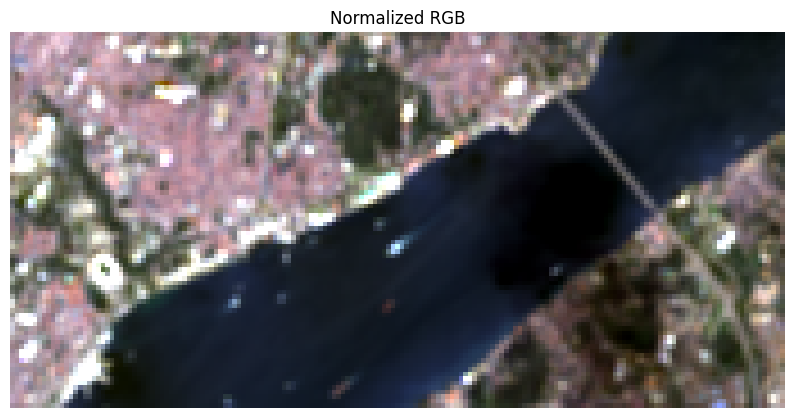

In [29]:
time_to_visualize = '2023-08-19'
bands = ["red", "green", "blue"]

da_time = stac.sel(time=time_to_visualize)
da_composite = da_time.sel(band=bands)

band1 = da_composite[0]
band1_normalized = normalize(band = band1)
band2 = da_composite[1]
band2_normalized = normalize(band = band2)
band3 = da_composite[2]
band3_normalized = normalize(band = band3)
composite = np.dstack((band1_normalized, band2_normalized, band3_normalized))

# Plot the image
plt.figure(figsize=(10, 5))
plt.imshow(composite)
plt.title("Normalized RGB")
plt.axis("off")
plt.show()

### 9.3 COP DEM GLO-30

In [10]:
missions().iloc[4]

name                                                   cop_dem_glo_30
allias                                                        cop_dem
stac_catalog                https://stac.terrabyte.lrz.de/public/api/
default_resolution                                              False
bands                                                           False
indices                                                         False
topographic_features    [slope, aspect, d_inf_flow_accumulation, twi]
max_cc                                                          False
clip_raster                                             [True, False]
cloud_masking                                                   False
output                                              path/to/output.nc
aggregator                                                      False
stats                                                           False
update                                                          False
animation           

In [2]:
mission = "cop_dem"                              
polygon = "./polygons/test.gpkg"                                                                     
clip_raster = False                                                         
output = None
topographic_features = ["slope", "aspect", "d_inf_flow_accumulation", "twi"]                                                                                            

In [ ]:
stac = get_stac_layers(mission=mission, polygon=polygon, 
                            clip_raster=clip_raster, 
                            output=output,
                            topographic_features=topographic_features)

In [ ]:
stac